# **Capstone Project: [Deteksi Penyakit pada Tanaman Kelapa Sawit]**
**ID Group:** LAI25-RM112

**Anggota Kelompok:**
- A200YBF418_Refanda Surya Saputra - A200YBF418@devacademy.id
- A270YAF435_Risky Fahriza - A270YAF435@devacademy.id
- A528YBF449_Sebastian Luth Hasibuan - A528YBF449@devacademy.id
- A184YBF450_Sefza Auma Alam - A184YBF450@devacademy.id

## **Import Libraries/Packages**

In [1]:
import os
import random
import shutil
import warnings
import zipfile

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import tensorflow as tf
from keras import Model, layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.layers import InputLayer, Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, AveragePooling2D
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import TFSMLayer, Input, Flatten
from tensorflow.keras.callbacks import Callback
from tensorflow.saved_model import save

from PIL import Image
from skimage import io
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.transform import rotate, AffineTransform, warp
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from tqdm.notebook import tqdm as tq

import gdown
from google.colab import drive

warnings.simplefilter(action='ignore', category=FutureWarning)

print(tf.__version__)

2025-05-27 07:51:59.855835: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748332320.053965      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748332320.117694      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


2.18.0


## **Loading Data**

### **Preparation Data**

#### Using Google Colab

In [ ]:
# Mounting dari google drive
drive.mount('/content/drive')

# Mengakses dataset di google drive
dataset_path = '/content/drive/My Drive/Capstone LAI25-RM112/Dataset/palm-disease-dataset.zip'

# Ekstrak dataset
with zipfile.ZipFile(dataset_path, 'r') as zip_file:
    zip_file.extractall('/content/dataset')

#### Using Local Device

In [2]:
# Ketika menggunakan IDE lokal
file_id = "1c9iWUpGHYl-eq057RheOT6q2-hcpj9F4"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, 'palm-disease-dataset.zip', quiet=False)

# Unzip berkas yang telah diuduh dari google drive
with zipfile.ZipFile('palm-disease-dataset.zip', 'r') as zip_file:
    zip_file.extractall()

Downloading...
From (original): https://drive.google.com/uc?id=1c9iWUpGHYl-eq057RheOT6q2-hcpj9F4
From (redirected): https://drive.google.com/uc?id=1c9iWUpGHYl-eq057RheOT6q2-hcpj9F4&confirm=t&uuid=6672ab3c-9b83-4f34-8381-a2537fd4c3a9
To: /kaggle/working/palm-disease-dataset.zip
100%|██████████| 779M/779M [00:10<00:00, 73.9MB/s] 


'palm-disease-dataset.zip'

#### Using Kaggle Notebook

In [2]:
# Ketika menggunakan Kaggle Notebook
kaggle_input_path = '/kaggle/input/palm-disease-dataset/palm-disease-dataset'

kaggle_output_path = '/kaggle/working/palm-disease-dataset'

if not os.path.exists(kaggle_output_path):
    os.makedirs(kaggle_output_path)

try:
    shutil.copytree(kaggle_input_path, kaggle_output_path, dirs_exist_ok=True)
    print(f"Berhasil menyalin dataset dari '{kaggle_input_path}' ke {kaggle_output_path}")
except Exception as e:
    print(f"Unexpected error: {e}")

Berhasil menyalin dataset dari '/kaggle/input/palm-disease-dataset/palm-disease-dataset' ke /kaggle/working/palm-disease-dataset


### **Checking Dataset**

In [3]:
# Mengecek label pada dataset

# Ketika menggunakan kaggle, hapus komentar pada baris kode di bawah ini
palm_disease_path = "/kaggle/working/palm-disease-dataset"

# Ketika menggunakan google colab atau lokal device hapus komentar pada baris kode di bawah ini
#palm_disease_path = "/dataset/palm-disease-dataset"

# Menyimpan label
list_label = os.listdir(palm_disease_path)

# Menampilkan list label
list_label

['Healthy', 'Scale Insect', 'Fungal Disease', 'Magnesium Deficiency']

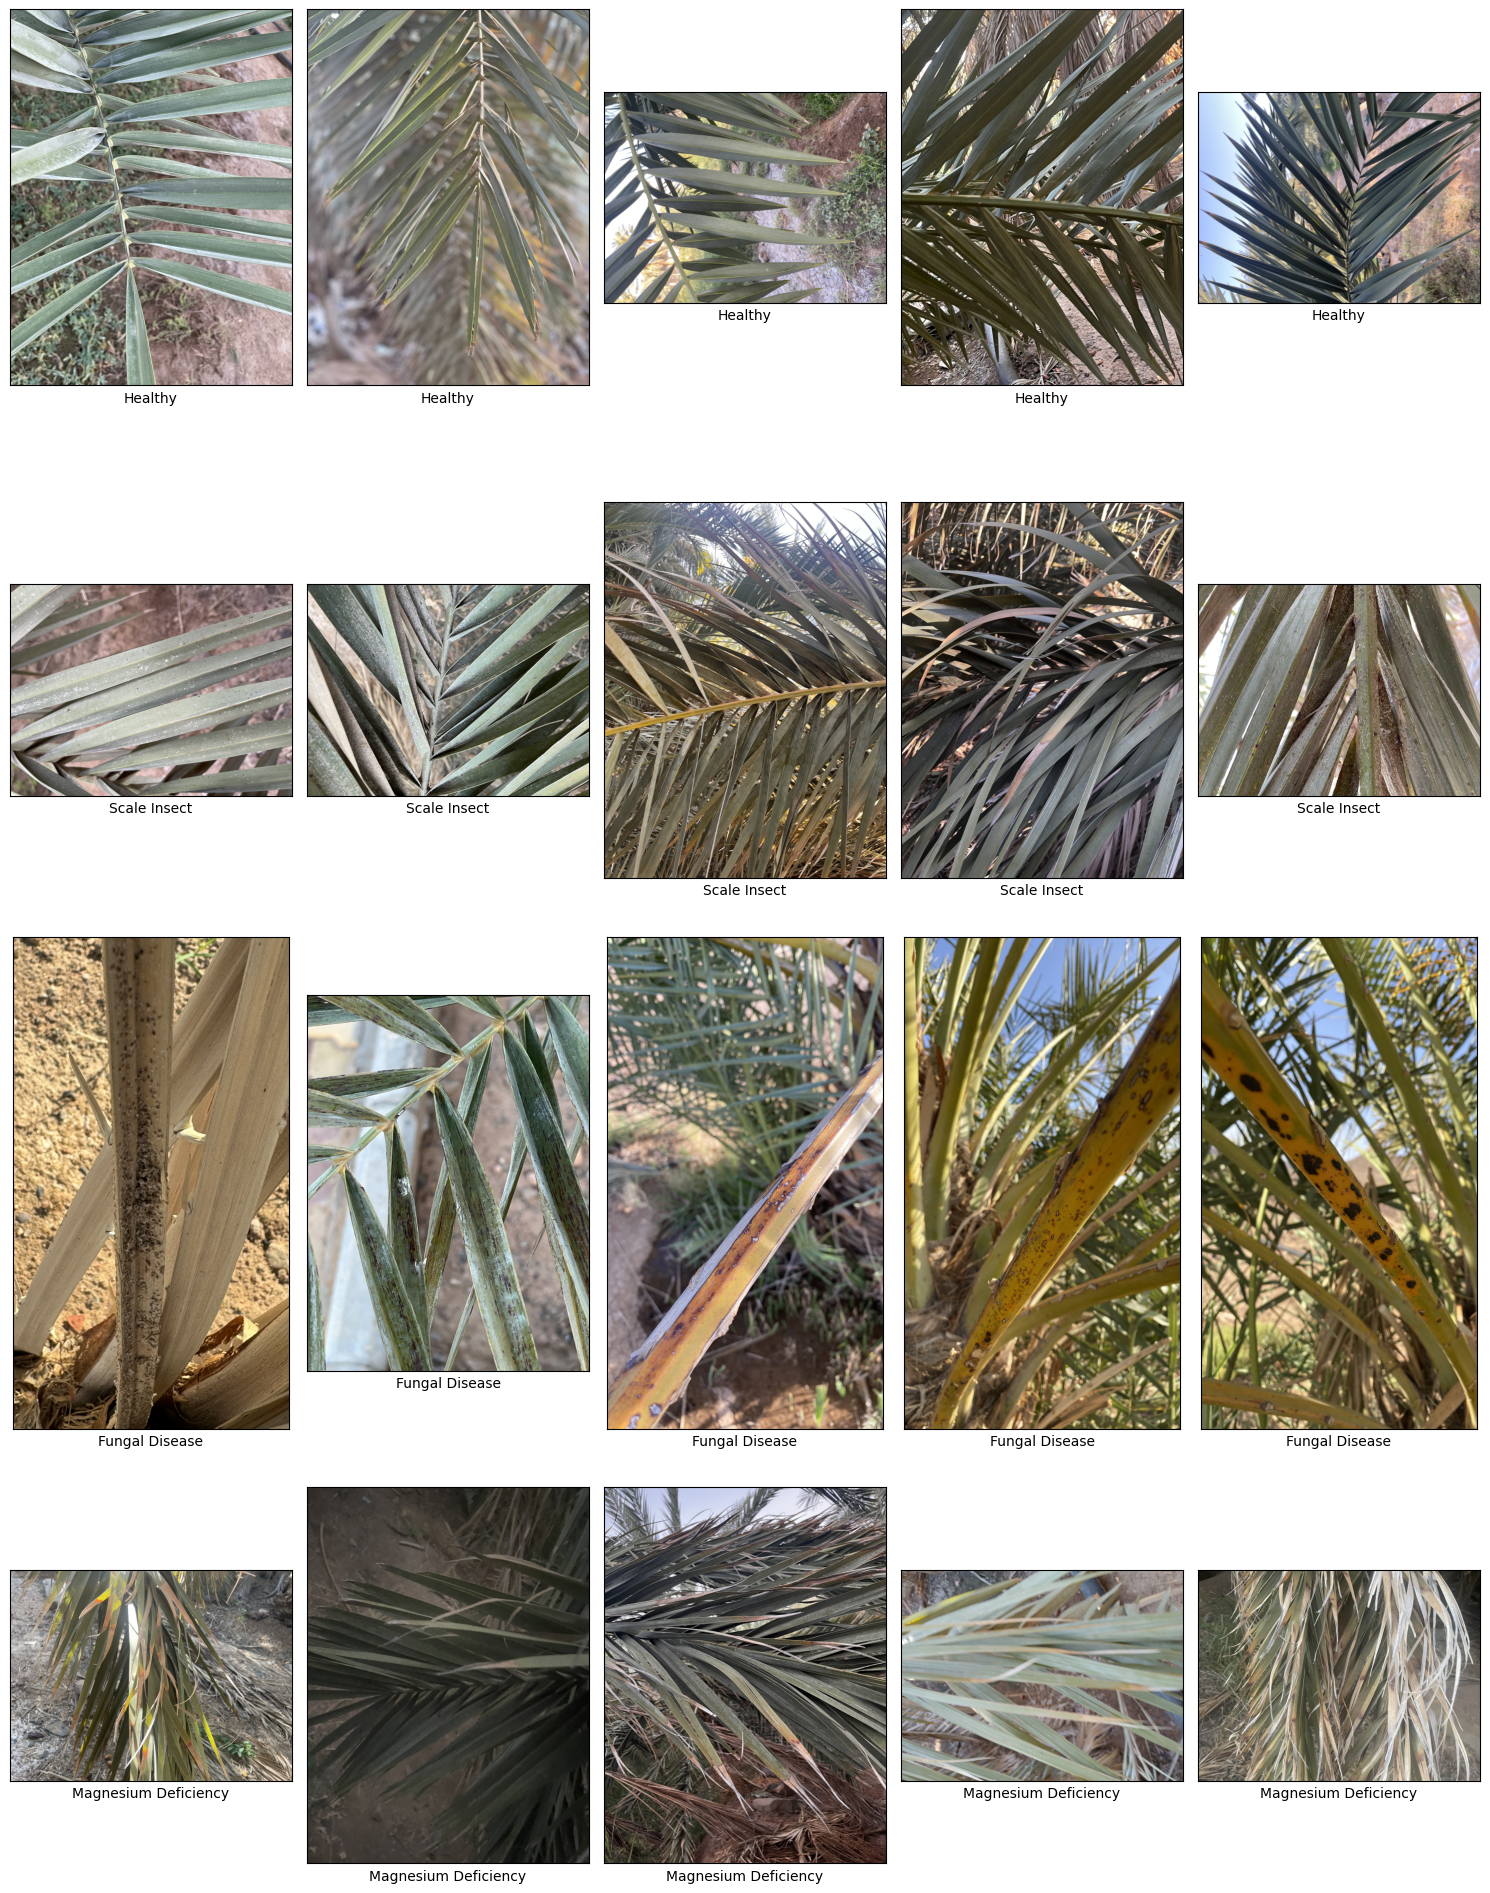

In [4]:
# Membuat dictionary untuk menyimpan gambar untuk setiap kelas dalam data
palm_disease_image = {}

# Menentukan path sumber dataset

# Hapus komentar pada kode ini jika menggunakan Kaggle Notebook
source_path = "/kaggle/working/palm-disease-dataset/"

# Hapus komentar pada kode ini jika menggunakan lokal device atau Google Colab
#source_path = "/dataset/palm-disease-dataset/"

for i in os.listdir(source_path):
  palm_disease_image[i]  = os.listdir(source_path + i)

# menampilkan secara acak 5 gambar untuk masing-masing kelas
fig, ax = plt.subplots(4, 5, figsize=(15, 20))

for i, label in enumerate(os.listdir(source_path)):
  images = np.random.choice(palm_disease_image[label], 5, replace=False)
  for j, image in enumerate(images):
    img_path = os.path.join(source_path, label, image)
    img = Image.open(img_path)
    ax[i, j].imshow(img)
    ax[i, j].set(xlabel=label, xticks=[], yticks=[])

fig.tight_layout()

In [6]:
# Membuat fungsi untuk melihat jumlah image tiap-tiap kelas
def get_image_count(path):
  image_count = {}
  for label in os.listdir(path):
    image_count[label] = len(os.listdir(os.path.join(path, label)))
  return image_count

print(get_image_count(source_path))

{'Healthy': 37, 'Scale Insect': 80, 'Fungal Disease': 53, 'Magnesium Deficiency': 69}


### **Distribution Plot of Class Dataset**

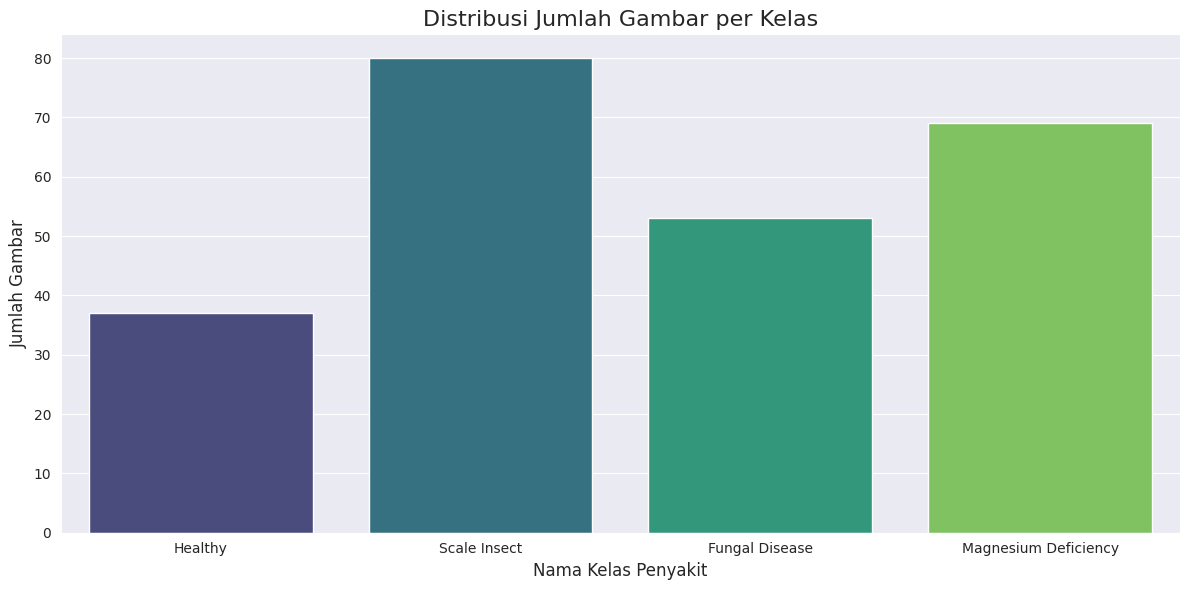

In [7]:
def plot_distribution(path):
  # Membuat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
  file_name = []
  labels = []
  full_path = []

  # Mendapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai DataFrame
  for path, subdirs, files in os.walk(path):
    for name in files:
      file_name.append(name)
      labels.append(path.split('/')[-1])
      full_path.append(os.path.join(path, name))

  distribution_train = pd.DataFrame({
      'path': full_path,
      'file_name': file_name,
      'labels': labels
  })
  for name in files:
      file_name.append(name)
      labels.append(path.split('/')[-1])

  # Plot distribusi gambar setiap kelas
  plt.figure(figsize=(12, 6))
  sns.set_style('darkgrid')
  sns.countplot(data=distribution_train, x='labels', palette='viridis')
    
  plt.title("Distribusi Jumlah Gambar per Kelas", fontsize=16)
  plt.xlabel("Nama Kelas Penyakit", fontsize=12)
  plt.ylabel("Jumlah Gambar", fontsize=12)
  plt.tight_layout() 
  plt.show()

plot_distribution(source_path)

## **Preprocessing Data**


### **Augmentation Data**

In [8]:
# Membuat fungsi untuk melakukan rotasi berlawanan arah jarum jam
def anticlockwise_rotation(img):
  img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
  img = cv2.resize(img, (224, 224))
  angle = random.randint(0, 180)
  return rotate(img, angle)

# Membuat fungsi untuk melakukan rotasi searah jarum ram
def clockwise_rotation(img):
  img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
  img = cv2.resize(img, (224, 224))
  angle = random.randint(0, 180)
  return rotate(img, -angle)

# Membuat fungsi untuk memberikan efek peningkatan kecerahan pada gambar
def add_brightness(img):
  img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
  img = cv2.resize(img, (224, 224))
  img = adjust_gamma(img, gamma=0.5)
  return img

# Membuat fungsi untuk memberikan efek pergeseran acak pada gambar
def sheared(img):
  img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
  img = cv2.resize(img, (224, 224))
  transform = AffineTransform(shear=0.2)
  shear_img = warp(img, transform, mode='wrap')
  return shear_img

# Membuat fungsi untuk melakukan pergeseran melengkung pada gambar
def warp_shift(img):
  img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
  img = cv2.resize(img, (224, 224))
  transform = AffineTransform(translation=(0, 40))
  warp_img = warp(img, transform, mode='wrap')
  return warp_img

In [9]:
# Membuat varabel transofrmasi yang akan menyimpan semua proses pra-pemrosesan yang telah dilakukan sebelumnya
transformations = {
    'anticlockwise_rotation': anticlockwise_rotation,
    'clockwise_rotation': clockwise_rotation,
    'add_brightness': add_brightness,
    'sheared': sheared,
    'warp_shift': warp_shift
}

def generate_augmented_image(image_class_name, source_image_path, num_augmented_images):
  img_processed_path = os.path.join(source_image_path, image_class_name)

  processed_images = []

  for img in os.listdir(img_processed_path):
    processed_images.append(os.path.join(img_processed_path, img))

  images_to_generate = num_augmented_images - len(os.listdir(img_processed_path))

  i = 1

  while i <= images_to_generate:
    random_image = random.choice(processed_images)

    try:
      original_image = io.imread(random_image)
      transformed_image = None

      num_transformations_to_apply = random.randint(1, len(transformations))

      num_transformations = 0

      while num_transformations <= num_transformations_to_apply:
        key = random.choice(list(transformations))
        transformed_image = transformations[key](original_image)
        num_transformations += 1

      new_image_path = "%s/augmented_image_%s.jpg" % (img_processed_path, i)
      transformed_image = img_as_ubyte(transformed_image)
      cv2.imwrite(new_image_path, transformed_image)
      i += 1
    except Exception as e:
      print('Could not read the', image, ':', e, 'hence skipping it.')

In [10]:
source_path = '/kaggle/working/palm-disease-dataset/'

for label in list_label:
  generate_augmented_image(label, source_path, 300)

Could not read the IMG_6355.jpg : Could not find a backend to open `/kaggle/working/palm-disease-dataset/Magnesium Deficiency/M6_50`` with iomode `r`. hence skipping it.
Could not read the IMG_6355.jpg : Could not find a backend to open `/kaggle/working/palm-disease-dataset/Magnesium Deficiency/M6_50`` with iomode `r`. hence skipping it.
Could not read the IMG_6355.jpg : Could not find a backend to open `/kaggle/working/palm-disease-dataset/Magnesium Deficiency/M6_63`` with iomode `r`. hence skipping it.
Could not read the IMG_6355.jpg : Could not find a backend to open `/kaggle/working/palm-disease-dataset/Magnesium Deficiency/M6_64`` with iomode `r`. hence skipping it.
Could not read the IMG_6355.jpg : Could not find a backend to open `/kaggle/working/palm-disease-dataset/Magnesium Deficiency/M6_50`` with iomode `r`. hence skipping it.
Could not read the IMG_6355.jpg : Could not find a backend to open `/kaggle/working/palm-disease-dataset/Magnesium Deficiency/M6_50`` with iomode `r`.

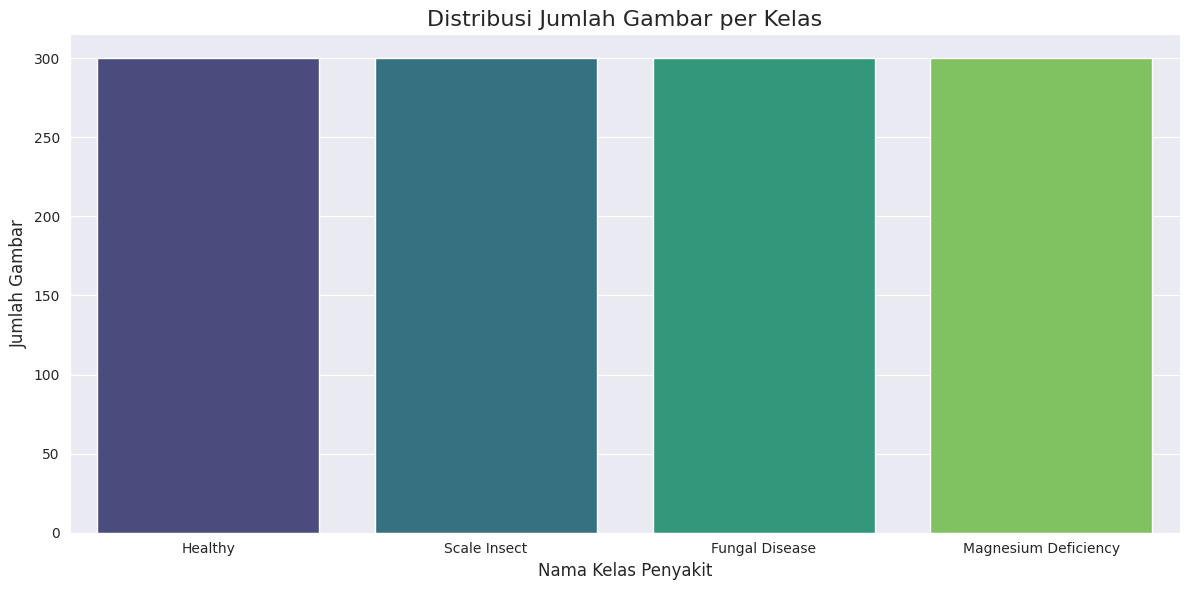

In [11]:
# Melihat plot distribusi kelas setelah dilakukan augmentasi
plot_distribution(source_path)

### **Spliting Data**

In [12]:
# Membuat variabel untuk menampung lokasi folder dari dataset gambar

# Hapus komentar pada kode ini jika menggunakan Google Colab atau lokal device
#source_path = '/dataset/palm-disease-dataset/'

# Hapus komentar pada kode ini jika menggunakan Kaggle Notebook
source_path = '/kaggle/working/palm-disease-dataset/'

file_name = []
labels = []
full_path = []

for path, subdirs, files in os.walk(source_path):
  for name in files:
    file_name.append(name)
    labels.append(path.split('/')[-1])
    full_path.append(os.path.join(path, name))

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah DataFrame
image_df = pd.DataFrame({
    'file_name': file_name,
    'labels': labels,
    'full_path': full_path
})

# Melihat jumlah data gambar pada masing-masing label
image_df['labels'].value_counts()

labels
Healthy                 300
Scale Insect            300
Fungal Disease          300
Magnesium Deficiency    300
Name: count, dtype: int64

In [13]:
# variabel yang digunaka pada pemisahan data ini, di mana variabel x = data path dan y = data labels
X = image_df['full_path']
y = image_df['labels']

# Split dataset awal menjadi data train dan temp (test dan validasi)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Menyatukan ke dalam maisng-masing DataFrame
df_train = pd.DataFrame({
    'path': X_train,
    'labels': y_train,
    'set': 'train'
})

df_validation = pd.DataFrame({
    'path': X_val,
    'labels': y_val,
    'set': 'validation'
})

df_test = pd.DataFrame({
    'path': X_test,
    'labels': y_test,
    'set': 'test'
})

# Menggabungkan DataFrame df_train, df_test, dan df_validation
df_all = pd.concat([df_train, df_validation, df_test], ignore_index=True)
print(df_all.groupby(['set', 'labels']).size())

set         labels              
test        Fungal Disease           45
            Healthy                  45
            Magnesium Deficiency     45
            Scale Insect             45
train       Fungal Disease          210
            Healthy                 210
            Magnesium Deficiency    210
            Scale Insect            210
validation  Fungal Disease           45
            Healthy                  45
            Magnesium Deficiency     45
            Scale Insect             45
dtype: int64


In [14]:
# Mengecek sampel data
print(df_all.sample(5))

                                                  path                labels  \
841  /kaggle/working/palm-disease-dataset/Healthy/a...               Healthy   
919  /kaggle/working/palm-disease-dataset/Magnesium...  Magnesium Deficiency   
235  /kaggle/working/palm-disease-dataset/Scale Ins...          Scale Insect   
977  /kaggle/working/palm-disease-dataset/Magnesium...  Magnesium Deficiency   
754  /kaggle/working/palm-disease-dataset/Healthy/a...               Healthy   

            set  
841  validation  
919  validation  
235       train  
977  validation  
754       train  


In [15]:
# Memanggil dataset asli yang berisi keseluruhan data gambar yang sesuai dengan labelnya

# Hapus komentar pada kode ini jika menggunakan Google Colab atau lokal device
#datasource_path = 'dataset/palm-disease-dataset/'

# Hapus komentar pada kode ini jika menggunakan Kaggle Notebook
datasource_path = '/kaggle/working/palm-disease-dataset/'

# Membuat variabel dataset, tempat menampung data yang telah dilakukan splitting

# Hapus komentar pada kode ini jika menggunakan Google Colab atau lokal device
#dataset_path = 'dataset/final-dataset/'

# Hapus komentar pada kode ini jika menggunakan Kaggle Notebook
dataset_path = '/kaggle/working/final-dataset/'

for index, row in tq(df_all.iterrows()):
  file_path = row['path']

  if os.path.exists(file_path) == False:
    file_path = os.path.join(datasource_path, row['labels'], row['image'].split('.')[0])

  # Membuat direktori tujuan folder
  if os.path.exists(os.path.join(dataset_path, row['set'], row['labels'])) == False:
    os.makedirs(os.path.join(dataset_path, row['set'], row['labels']))

  # Menentukan tujuan file
  destination_file_name = file_path.split('/')[-1]
  destination_path = os.path.join(dataset_path, row['set'], row['labels'], destination_file_name)

  # Memindahkan file ke direktori tujuan
  if os.path.exists(destination_path) == False:
    shutil.copy2(file_path, destination_path)

0it [00:00, ?it/s]

### **Image Data Generator**

In [16]:
# Mendefinisikan direktori daset training, test, dan validation

# Hapus komentar pada kode di bawah ini jika menggunakan Google Colab atau device lokal
# TRAIN_DIR = "dataset/final-dataset/train"
# TEST_DIR = "dataset/final-dataset/test"
# VAL_DIR = "dataset/final-dataset/validation"

# Hapus komentar pada kode di bawah ini jika menggunakan Kaggle Notebook
TRAIN_DIR = '/kaggle/working/final-dataset/train'
TEST_DIR = '/kaggle/working/final-dataset/test'
VAL_DIR = '/kaggle/working/final-dataset/validation'

# Membuat fungsi untuk menampilkan jumlah data train berdasarkan label
def print_total_train_data(label):
  train_temp = os.path.join(TRAIN_DIR, label)
  train_count = len(os.listdir(train_temp))
  print("Total train data for {} is {}".format(label, train_count))

# Membuat fungsi untuk menampilkan jumlah data test berdasarkan label
def print_total_test_data(label):
  test_temp = os.path.join(TEST_DIR, label)
  test_count = len(os.listdir(test_temp))
  print("Total test data for {} is {}".format(label, test_count))

# Membuat fungsi untuk menampilkan jumlah data validation berdasarkan label
def print_total_validation_data(label):
  val_temp = os.path.join(VAL_DIR, label)
  val_count = len(os.listdir(val_temp))
  print("Total validation data for {} is {}".format(label, val_count))

for label in list_label:
  print_total_train_data(label)
  print_total_test_data(label)
  print_total_validation_data(label)
  print("\n")

Total train data for Healthy is 210
Total test data for Healthy is 45
Total validation data for Healthy is 45


Total train data for Scale Insect is 210
Total test data for Scale Insect is 45
Total validation data for Scale Insect is 45


Total train data for Fungal Disease is 210
Total test data for Fungal Disease is 45
Total validation data for Fungal Disease is 45


Total train data for Magnesium Deficiency is 210
Total test data for Magnesium Deficiency is 45
Total validation data for Magnesium Deficiency is 45




In [17]:
# Membuat objek ImageDataGeneratir untuk menormalisasikan gambar
train_datagen = ImageDataGenerator(rescale=1. / 255)
test_datagen = ImageDataGenerator(rescale=1. / 255)
val_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    seed=42,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    seed=42,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    seed=42,
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical',
    shuffle=False
)

Found 836 images belonging to 4 classes.
Found 180 images belonging to 4 classes.
Found 180 images belonging to 4 classes.


## **Building Model**

### **Model Experiment 1**

In [18]:
# Inisialisasi model sekuensial
model_1 = Sequential()

model_1.add(Input(shape=(224, 224, 3)))

model_1.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model_1.add(BatchNormalization())
model_1.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2,2)))

model_1.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model_1.add(BatchNormalization())
model_1.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2,2)))

model_1.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model_1.add(BatchNormalization())
model_1.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2,2)))

model_1.add(GlobalAveragePooling2D())

model_1.add(Dense(128, activation='relu'))
model_1.add(Dropout(0.3))

# model_1.add(Dense(64, activation='relu'))
# model_1.add(Dropout(0.3))

model_1.add(Dense(len(list_label), activation='softmax'))

model_1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# rangkuman arsitektur model
model_1.summary()

I0000 00:00:1748332656.898785      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 224, 224, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 112, 112, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 56, 56, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 304,932 (1.16 MB)

 Trainable params: 304,484 (1.16 MB)

 Non-trainable params: 448 (1.75 KB)

In [19]:
# Membuat callback
checkpoint = ModelCheckpoint('model_1.h5', monitor='val_loss', save_best_only=True, mode='min')

# Membuat custom callback
class EpochCheckpoint(Callback):
  def on_epoch_end(self, epoch, logs={}):
    if (logs.get('accuracy') > 0.95):
      print("[INFO] Reached 95% accuracy, stopping training")
      self.model.stop_training = True

epoch_checkpoint = EpochCheckpoint()

In [20]:
# Fitting / training model
history_model_1 = model_1.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[checkpoint, epoch_checkpoint]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1748332676.474839     133 service.cc:148] XLA service 0x7d3cc4005d20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748332676.475530     133 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1748332677.350921     133 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/27 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.2344 - loss: 1.7541 

I0000 00:00:1748332686.353445     133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


27/27 ━━━━━━━━━━━━━━━━━━━━ 41s 983ms/step - accuracy: 0.3657 - loss: 1.4258 - val_accuracy: 0.2444 - val_loss: 1.3842
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 693ms/step - accuracy: 0.5036 - loss: 1.1293 - val_accuracy: 0.2500 - val_loss: 1.4319
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 704ms/step - accuracy: 0.5975 - loss: 0.9678 - val_accuracy: 0.2500 - val_loss: 1.5862
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 714ms/step - accuracy: 0.6274 - loss: 0.8881 - val_accuracy: 0.2611 - val_loss: 1.8580
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 717ms/step - accuracy: 0.6121 - loss: 0.9197 - val_accuracy: 0.2556 - val_loss: 1.9476
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 729ms/step - accuracy: 0.6307 - loss: 0.8885 - val_accuracy: 0.2556 - val_loss: 3.0413
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 719ms/step - accuracy: 0.6671 - loss: 0.8889 - val_accuracy: 0.2889 - val_loss: 2.7693
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 706ms/step - accuracy: 0.6971 - loss: 0.7321 - val_accuracy: 0.261

### **Model Experiment 2**

### **Model Experiment 3**

### **Model Transfer Learning**

## **Evaluating Model**

### **Evaluating Model 1**

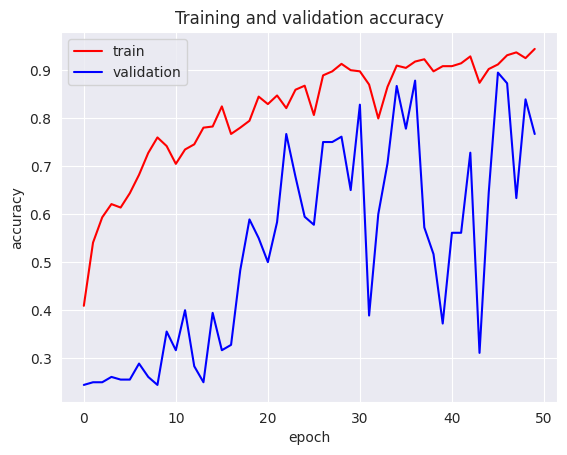

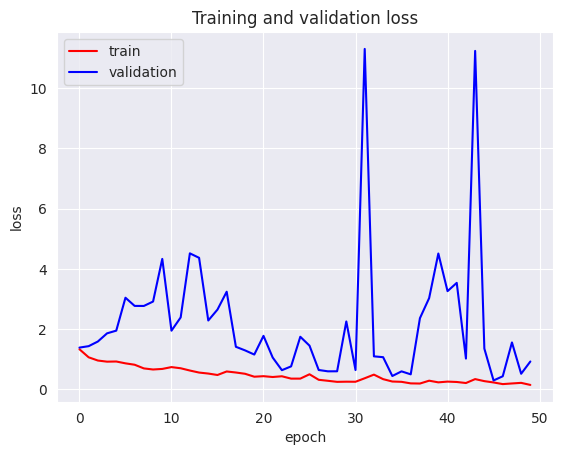

In [21]:
acc_1 = history_model_1.history['accuracy']
val_acc_1 = history_model_1.history['val_accuracy']
loss_1 = history_model_1.history['loss']
val_loss_1 = history_model_1.history['val_loss']

epochs = range(len(acc_1))

def plot_model_result(epochs, acc, val_acc, loss, val_loss):
  plt.plot(epochs, acc, 'r')
  plt.plot(epochs, val_acc, 'b')
  plt.title('Training and validation accuracy')
  plt.ylabel('accuracy')
  plt.xlabel('epoch')
  plt.legend(['train', 'validation'], loc='upper left')
  plt.show()

  plt.plot(epochs, loss, 'r')
  plt.plot(epochs, val_loss, 'b')
  plt.title('Training and validation loss')
  plt.ylabel('loss')
  plt.xlabel('epoch')
  plt.legend(['train', 'validation'], loc='upper left')
  plt.show()

plot_model_result(epochs, acc_1, val_acc_1, loss_1, val_loss_1)

In [22]:
# Evaluasi model menggunakan data pengujian
evaluation_model_1 = model_1.evaluate(test_generator)

# Menampilkan hasil evaluasi
print('Test Loss:', evaluation_model_1[0])
print('Test Accuracy:', evaluation_model_1[1])

180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8047 - loss: 0.8845
Test Loss: 0.792794942855835
Test Accuracy: 0.800000011920929


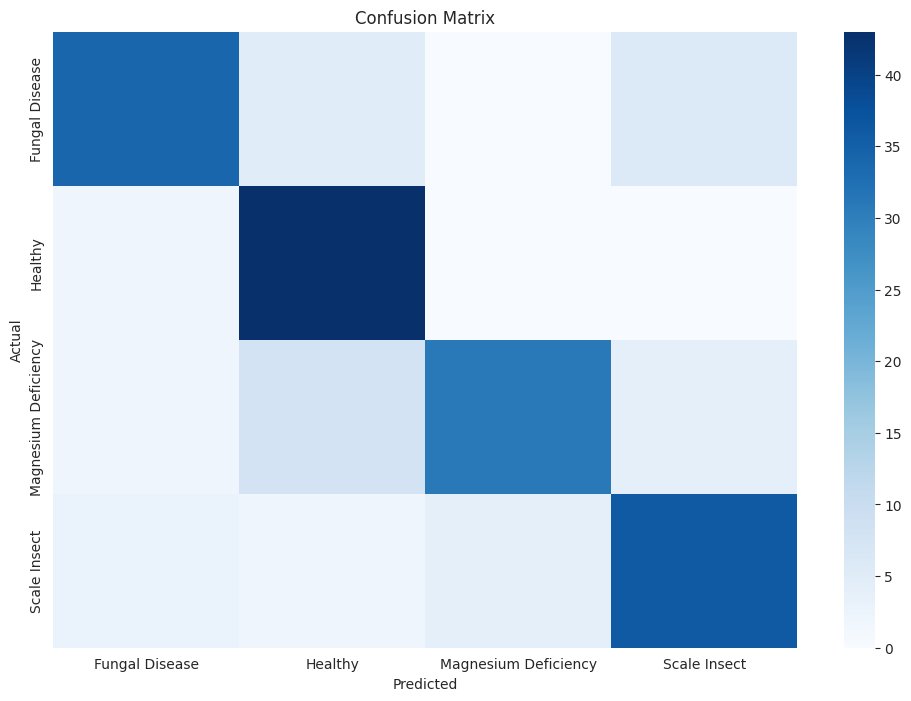

In [23]:
test_generator.reset()

preds_1 = model_1.predict(test_generator, verbose=0)
y_pred = preds_1.argmax(axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

# Menampilkan confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [24]:
# Menampilkan classification report
print(classification_report(y_true, y_pred, target_names=class_names))

                      precision    recall  f1-score   support

      Fungal Disease       0.83      0.76      0.79        45
             Healthy       0.74      0.96      0.83        45
Magnesium Deficiency       0.89      0.69      0.78        45
        Scale Insect       0.78      0.80      0.79        45

            accuracy                           0.80       180
           macro avg       0.81      0.80      0.80       180
        weighted avg       0.81      0.80      0.80       180



### **Evaluating Model 2**

### **Evaluating Model 3**

### **Evaluating Model Transfer Learning**

## **Converting Model**

Melakukan konversi model ke format SavedModel untuk model dengan akurasi dataset training dan test paling optimal

In [ ]:
# Konversi model ke format SavedModel
saved_path = 'model/saved_model'
save(model_1, saved_path)

## **Inferring Model**

Menggunakan model dengan nilai akurasi pada dataset test dan training paling optimal

In [ ]:
# Path ke model SavedModel
model_path = 'model/saved_model'

model = load_model('model_1.h5')